# Clustering Assignment

## Theoretical Questions

### Q1. What is unsupervised learning in the context of machine learning?

Unsupervised learning is a type of machine learning where the model is trained on data that has **no labels**.

The model tries to find patterns, groups, or structure in the data on its own — without being told what the correct answer is.

**Example:** Grouping customers into different categories based on their shopping habits — without telling the model how many groups to make or what each group means.

Common tasks in unsupervised learning:
- **Clustering** — grouping similar data points together
- **Dimensionality Reduction** — reducing the number of features
- **Anomaly Detection** — finding unusual data points

### Q2. How does K-Means clustering algorithm work?

K-Means is an algorithm that divides data into **K groups (clusters)**.

**Steps:**
1. Choose K (number of clusters)
2. Randomly place K centroids (center points) in the data
3. Assign each data point to the nearest centroid
4. Move each centroid to the average position of all points assigned to it
5. Repeat steps 3 and 4 until the centroids stop moving

**Simple words:** Imagine putting K magnets in a room full of iron balls. Each ball gets pulled to the nearest magnet. Then each magnet moves to the center of its group. This keeps repeating until everything settles.

### Q3. Explain the concept of a dendrogram in hierarchical clustering.

A **dendrogram** is a tree-shaped diagram that shows how clusters are merged (or split) step by step in hierarchical clustering.

- The **bottom** of the tree shows individual data points
- As you go **up**, similar points are merged into groups
- The **top** of the tree shows one big group containing all data

The **height** of each merge shows how different the two groups were — a higher merge means the groups were more different.

**Use:** You can cut the dendrogram at any height to get a desired number of clusters.

### Q4. What is the main difference between K-Means and Hierarchical Clustering?

| Feature | K-Means | Hierarchical Clustering |
|---|---|---|
| Need to give K? | Yes, before starting | No, decide after looking at dendrogram |
| Result | Flat clusters | Tree structure (dendrogram) |
| Speed | Fast | Slower (especially on big data) |
| Works well on | Round-shaped clusters | Any shape |
| Can undo merges? | No | No (agglomerative) |

**Simple words:** K-Means needs you to say how many groups you want first. Hierarchical clustering builds a tree and lets you decide the number of groups later.

### Q5. What are the advantages of DBSCAN over K-Means?

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** has these advantages over K-Means:

1. **No need to specify K** — DBSCAN finds the number of clusters on its own
2. **Finds clusters of any shape** — K-Means only works well with round clusters
3. **Handles noise/outliers** — DBSCAN marks unusual points as noise; K-Means forces every point into a cluster
4. **Better for real-world data** — Real data rarely has perfectly round clusters

**Example:** In a city map, DBSCAN can find oddly-shaped neighborhoods of dense population and mark empty areas as noise.

### Q6. When would you use Silhouette Score in clustering?

**Silhouette Score** is used to **evaluate how good your clustering is** — when you don't have true labels to compare with.

**When to use:**
- To find the best value of K in K-Means
- To compare two different clustering results
- To check if a data point is placed in the right cluster

**Score range:** -1 to +1
- Close to **+1** → data point is in the right cluster
- Close to **0** → data point is on the border between two clusters
- Close to **-1** → data point might be in the wrong cluster

### Q7. What are the limitations of Hierarchical Clustering?

1. **Slow on large data** — It computes distances between all pairs of points, which is very slow for big datasets
2. **Cannot undo merges** — Once two groups are merged, they stay merged (in agglomerative clustering)
3. **Sensitive to outliers** — Noisy points can mess up the tree structure
4. **Memory intensive** — Storing the distance matrix takes a lot of memory
5. **Hard to choose cut point** — Deciding where to cut the dendrogram is subjective

### Q8. Why is feature scaling important in clustering algorithms like K-Means?

K-Means uses **distance** to measure how close two points are. If one feature has values from 0 to 1 and another has values from 0 to 10,000, the second feature will **dominate the distance calculation**.

**Example:**
- Age: 25 to 60
- Salary: 20,000 to 100,000

Without scaling, salary will have a much bigger effect on clustering than age — even if age is equally important.

**Solution:** Use StandardScaler (mean=0, std=1) or MinMaxScaler (0 to 1) before clustering.

### Q9. How does DBSCAN identify noise points?

DBSCAN has two parameters:
- **eps** — the radius around a point to look for neighbors
- **min_samples** — minimum number of points needed inside that radius

**Types of points:**
- **Core point** — has at least min_samples neighbors within eps
- **Border point** — is within eps of a core point but doesn't have enough neighbors itself
- **Noise point** — is NOT within eps of any core point

**Noise points are labeled as -1** in DBSCAN output.

**Simple words:** If a point is too far away from any dense group, it's considered noise (an outlier).

### Q10. Define inertia in the context of K-Means.

**Inertia** is the total sum of squared distances between each data point and its cluster's centroid.

**Formula:** Inertia = sum of (distance from each point to its centroid)²

- **Lower inertia** = tighter, more compact clusters = better clustering
- **Higher inertia** = points are spread far from their centroids = worse clustering

**Use:** Inertia is used in the **Elbow Method** to find the best value of K.

**Note:** Inertia always decreases as K increases — so it can't be used alone.

### Q11. What is the elbow method in K-Means clustering?

The **Elbow Method** is a way to find the best number of clusters (K) in K-Means.

**How it works:**
1. Run K-Means for K = 1, 2, 3, 4, 5, ...
2. For each K, record the inertia
3. Plot K on x-axis and inertia on y-axis
4. Look for the **elbow point** — where the inertia stops decreasing quickly

**Why it works:** After the elbow point, adding more clusters gives very little improvement. The elbow is the sweet spot.

**Simple words:** It's like asking — at what point does adding more groups stop being useful?

### Q12. Describe the concept of "density" in DBSCAN.

In DBSCAN, **density** means how many data points are packed in a small area.

A region is considered **dense** if there are at least **min_samples** points within a radius of **eps** around a point.

**Dense area** → forms a cluster
**Sparse area** → considered noise

**Simple analogy:** Imagine people standing in a park. A group of 10 people standing close together is a dense region. A person standing alone far from any group is noise.

DBSCAN finds clusters based on these dense regions — it doesn't care about the shape of the cluster, only the density.

### Q13. Can hierarchical clustering be used on categorical data?

Yes, but you need to use an appropriate **distance measure** for categorical data.

Standard hierarchical clustering uses Euclidean distance, which doesn't work for categories.

**For categorical data, use:**
- **Hamming distance** — counts the number of positions where two items differ
- **Jaccard distance** — based on set overlap
- **Gower distance** — works for mixed data (numeric + categorical)

**Practical tip:** You can also **encode** categorical data (e.g., one-hot encoding) and then apply standard hierarchical clustering, but this can sometimes give poor results.

### Q14. What does a negative Silhouette Score indicate?

A **negative Silhouette Score** means a data point is **in the wrong cluster**.

It means the point is **closer to a neighboring cluster** than to the cluster it's currently assigned to.

**Score values:**
- **+1** → perfectly placed in its cluster
- **0** → on the boundary between two clusters
- **-1** → likely placed in the wrong cluster

**When you see many negative scores:** Your clustering is poor — either K is wrong, or the algorithm is not suitable for your data.

### Q15. Explain the term "linkage criteria" in hierarchical clustering.

**Linkage criteria** defines how the **distance between two clusters** is measured when merging them.

Different linkage methods give different results:

| Linkage | How distance is measured |
|---|---|
| **Single** | Distance between the two closest points in the clusters |
| **Complete** | Distance between the two farthest points in the clusters |
| **Average** | Average distance between all pairs of points |
| **Ward** | Minimizes the total variance within clusters |

**Simple words:** Before merging two clusters, you need to decide — how do you measure how far apart they are? That decision is the linkage criteria.

### Q16. Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?

K-Means assumes that all clusters are:
1. **Similar in size** (same number of points)
2. **Similar in density** (points are equally spread)
3. **Round in shape** (spherical clusters)

When clusters are **different sizes or densities**, K-Means tends to:
- Break large clusters into smaller ones
- Merge small clusters with nearby ones

**Why?** Because K-Means minimizes total distance, not cluster quality. It doesn't understand that one cluster might naturally have 1000 points and another might have only 50.

**Alternative:** Use DBSCAN or Gaussian Mixture Models for such data.

### Q17. What are the core parameters in DBSCAN, and how do they influence clustering?

DBSCAN has two main parameters:

**1. eps (ε) — Epsilon / Radius**
- Defines the neighborhood radius around each point
- **Small eps** → more points become noise, smaller clusters
- **Large eps** → all points merge into one big cluster

**2. min_samples — Minimum Points**
- Minimum number of points required to form a dense region (core point)
- **Small min_samples** → easier to form clusters, less noise detected
- **Large min_samples** → harder to form clusters, more noise detected

**Tip for choosing:**
- Use a **k-distance graph** to find a good eps value
- A common starting value for min_samples is `2 × number_of_features`

### Q18. How does K-Means++ improve upon standard K-Means initialization?

**Standard K-Means** picks initial centroids randomly. This can lead to:
- Bad starting positions
- Slow convergence
- Poor final clusters

**K-Means++** uses a smarter initialization:
1. Pick the first centroid randomly
2. For each remaining centroid, pick the next one with **probability proportional to its distance** from existing centroids
3. This spreads the initial centroids far apart

**Benefits:**
- Faster convergence
- More consistent results
- Better final clusters

**Note:** In scikit-learn, `KMeans(init='k-means++')` is the default.

### Q19. What is agglomerative clustering?

**Agglomerative clustering** is a type of hierarchical clustering that works **bottom-up**.

**How it works:**
1. Start with each data point as its own cluster
2. Find the two closest clusters
3. Merge them into one cluster
4. Repeat until only one big cluster remains

**Simple analogy:** Imagine each student in a class is alone at first. Then the two students sitting closest together form a group. Then the two closest groups merge. This keeps going until everyone is in one big group.

The result is shown as a **dendrogram**. You can cut the tree at any level to get your desired number of clusters.

### Q20. What makes Silhouette Score a better metric than just inertia for model evaluation?

| Aspect | Inertia | Silhouette Score |
|---|---|---|
| **What it measures** | How compact each cluster is | How well-separated clusters are from each other |
| **Always improves with more K?** | Yes (always goes down) | No (peaks at the right K) |
| **Considers other clusters?** | No | Yes |
| **Range** | 0 to infinity | -1 to +1 |

**Key reason:** Inertia only measures how tight each cluster is — but it doesn't check if clusters are well **separated** from each other. You could have 100 tiny clusters with very low inertia, but they might all be touching.

Silhouette Score considers **both** tightness (within cluster) and separation (between clusters), making it a more balanced metric.

## Practical Questions

### Q21. Generate synthetic data with 4 centers using make_blobs and apply K-Means clustering. Visualize using a scatter plot.

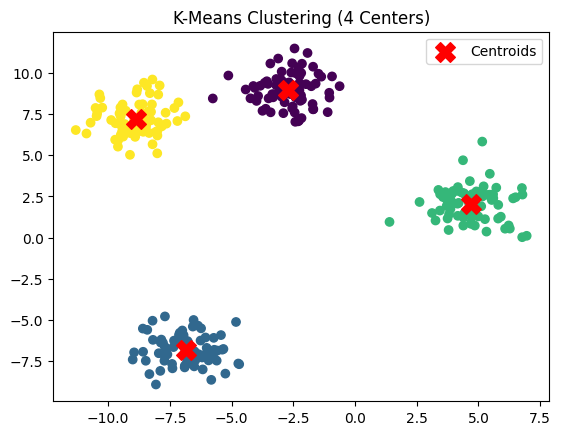

In [1]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Generate synthetic data with 4 centers
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

# Apply K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

# Scatter plot
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centroids')
plt.title('K-Means Clustering (4 Centers)')
plt.legend()
plt.show()

### Q22. Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters. Display the first 10 predicted labels.

In [2]:
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

# Load Iris dataset
iris = load_iris()
X = iris.data

# Apply Agglomerative Clustering with 3 clusters
agg = AgglomerativeClustering(n_clusters=3)
labels = agg.fit_predict(X)

# Display first 10 labels
print('First 10 predicted labels:', labels[:10])

First 10 predicted labels: [1 1 1 1 1 1 1 1 1 1]


### Q23. Generate synthetic data using make_moons and apply DBSCAN. Highlight outliers in the plot.

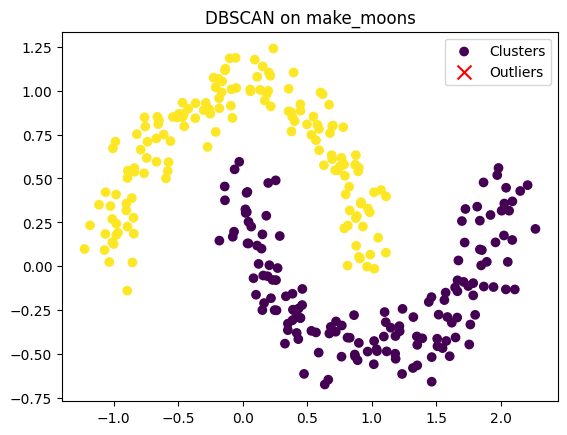

In [3]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Generate moon-shaped data
X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

# Plot: outliers are label = -1
outliers = labels == -1
plt.scatter(X[~outliers, 0], X[~outliers, 1], c=labels[~outliers], cmap='viridis', label='Clusters')
plt.scatter(X[outliers, 0], X[outliers, 1], c='red', marker='x', s=100, label='Outliers')
plt.title('DBSCAN on make_moons')
plt.legend()
plt.show()

### Q24. Load the Wine dataset and apply K-Means clustering after standardizing the features. Print the size of each cluster.

In [4]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# Load Wine dataset
wine = load_wine()
X = wine.data

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Print size of each cluster
unique, counts = np.unique(labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f'Cluster {cluster}: {count} samples')

Cluster 0: 65 samples
Cluster 1: 51 samples
Cluster 2: 62 samples


### Q25. Use make_circles to generate synthetic data and cluster it using DBSCAN. Plot the result.

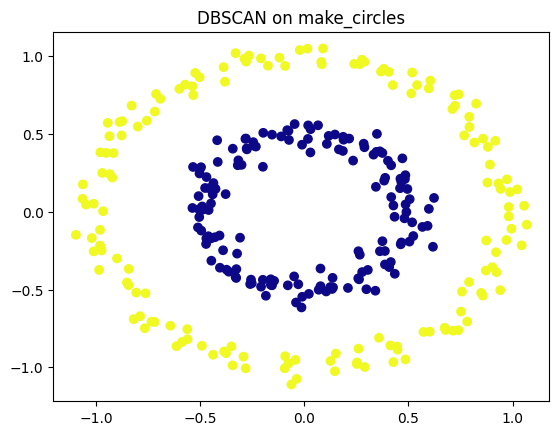

In [5]:
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Generate circular data
X, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

# Plot
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma')
plt.title('DBSCAN on make_circles')
plt.show()

### Q26. Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters. Output the cluster centroids.

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# Load data
cancer = load_breast_cancer()
X = cancer.data

# Scale using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

# Print centroids
print('Cluster Centroids (first 5 features):')
print(kmeans.cluster_centers_[:, :5])

Cluster Centroids (first 5 features):
[[0.50483563 0.39560329 0.50578661 0.36376576 0.46988732]
 [0.25535358 0.28833455 0.24696416 0.14388369 0.35743076]]


### Q27. Generate synthetic data using make_blobs with varying cluster standard deviations and cluster with DBSCAN.

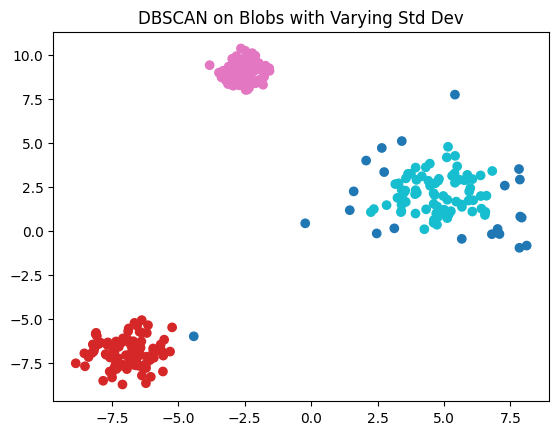

In [7]:
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Make blobs with different standard deviations
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=[0.5, 1.5, 0.8], random_state=42)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels = dbscan.fit_predict(X)

# Plot
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10')
plt.title('DBSCAN on Blobs with Varying Std Dev')
plt.show()

### Q28. Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means.

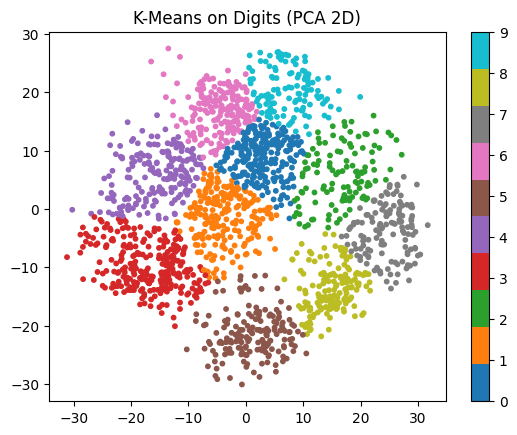

In [8]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load digits dataset
digits = load_digits()
X = digits.data

# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# Apply K-Means with 10 clusters (10 digits)
kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(X_2d)

# Visualize
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=10)
plt.title('K-Means on Digits (PCA 2D)')
plt.colorbar()
plt.show()

### Q29. Create synthetic data using make_blobs and evaluate silhouette scores for k = 2 to 5. Display as a bar chart.

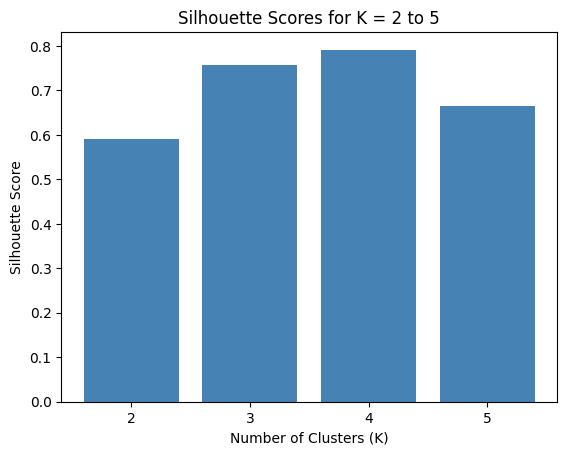

In [9]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

k_values = [2, 3, 4, 5]
scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

# Bar chart
plt.bar([str(k) for k in k_values], scores, color='steelblue')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for K = 2 to 5')
plt.show()

### Q30. Load the Iris dataset and use hierarchical clustering to group data. Plot a dendrogram with average linkage.

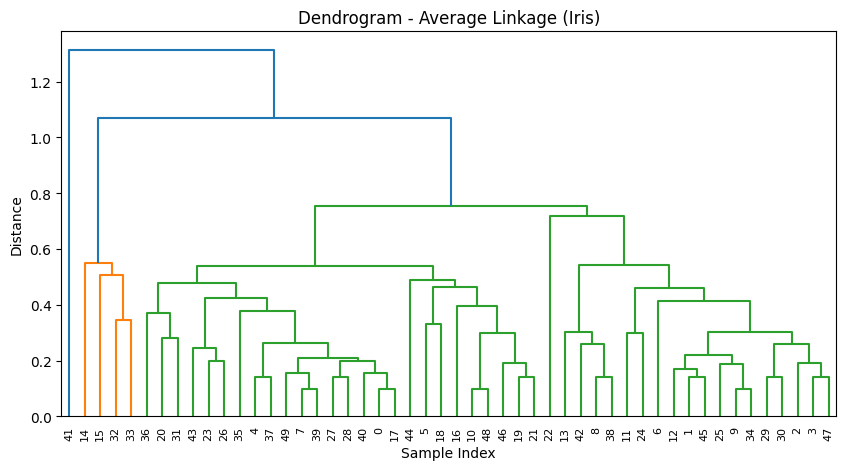

In [10]:
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Load Iris
iris = load_iris()
X = iris.data[:50]  # Use first 50 samples for clarity

# Average linkage
linked = linkage(X, method='average')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.title('Dendrogram - Average Linkage (Iris)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

### Q31. Generate synthetic data with overlapping clusters using make_blobs, then apply K-Means and visualize with decision boundaries.

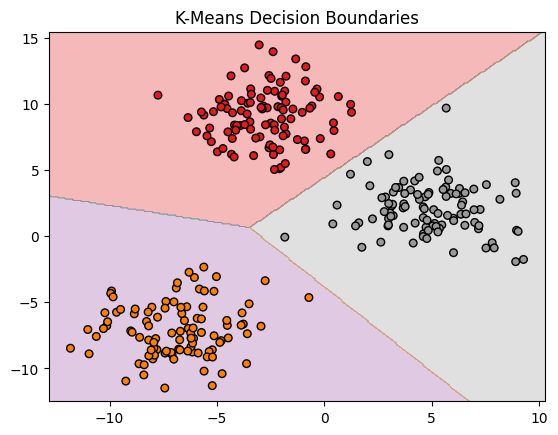

In [11]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Overlapping clusters
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=2.0, random_state=42)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Create mesh grid for decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='Set1', edgecolors='k', s=30)
plt.title('K-Means Decision Boundaries')
plt.show()

### Q32. Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE. Visualize the results.

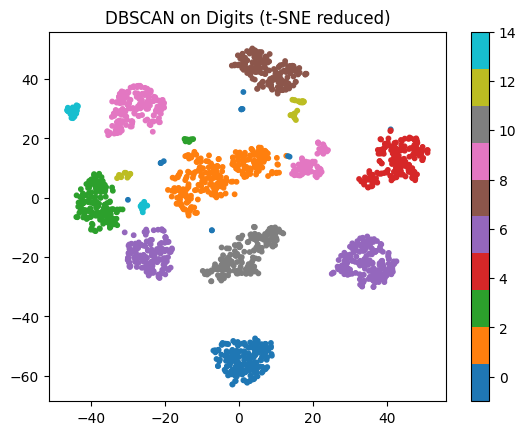

In [12]:
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

digits = load_digits()
X = digits.data

# Reduce with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=3, min_samples=5)
labels = dbscan.fit_predict(X_tsne)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=10)
plt.title('DBSCAN on Digits (t-SNE reduced)')
plt.colorbar()
plt.show()

### Q33. Generate synthetic data using make_blobs and apply Agglomerative Clustering with complete linkage. Plot the result.

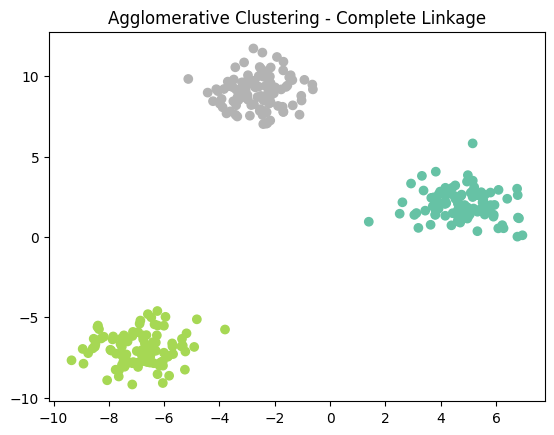

In [13]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=3, random_state=42)

# Agglomerative with complete linkage
agg = AgglomerativeClustering(n_clusters=3, linkage='complete')
labels = agg.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='Set2')
plt.title('Agglomerative Clustering - Complete Linkage')
plt.show()

### Q34. Load the Breast Cancer dataset and compare inertia values for K = 2 to 6 using K-Means. Show results in a line plot.

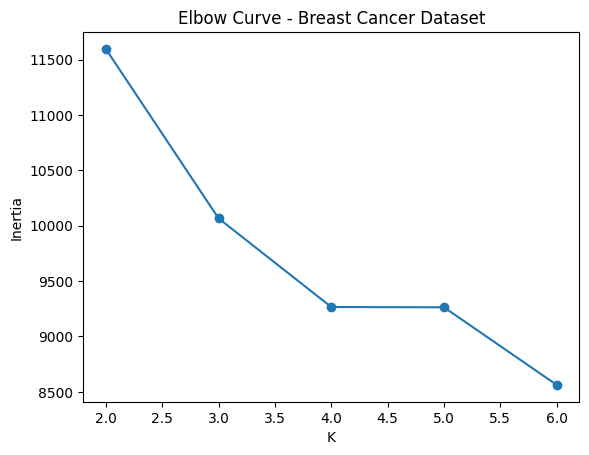

In [14]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

cancer = load_breast_cancer()
X = StandardScaler().fit_transform(cancer.data)

k_values = range(2, 7)
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(list(k_values), inertias, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Curve - Breast Cancer Dataset')
plt.show()

### Q35. Generate synthetic concentric circles using make_circles and cluster using Agglomerative Clustering with single linkage.

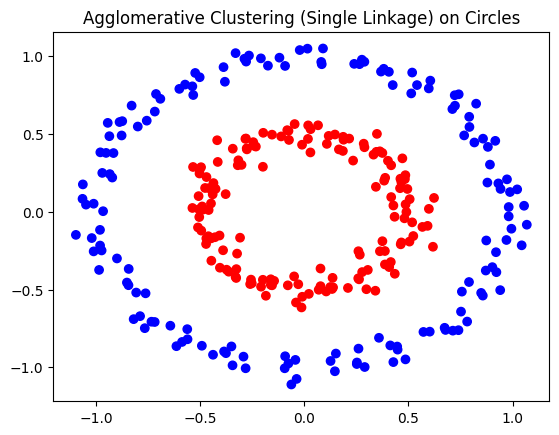

In [15]:
from sklearn.datasets import make_circles
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

# Single linkage
agg = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = agg.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='bwr')
plt.title('Agglomerative Clustering (Single Linkage) on Circles')
plt.show()

### Q36. Use the Wine dataset, apply DBSCAN after scaling the data, and count the number of clusters (excluding noise).

In [16]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

wine = load_wine()
X = StandardScaler().fit_transform(wine.data)

dbscan = DBSCAN(eps=2.5, min_samples=5)
labels = dbscan.fit_predict(X)

# Count clusters (exclude noise = -1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f'Number of clusters (excluding noise): {n_clusters}')
print(f'Noise points: {list(labels).count(-1)}')

Number of clusters (excluding noise): 1
Noise points: 24


### Q37. Generate synthetic data with make_blobs and apply KMeans. Then plot the cluster centers on top of the data points.

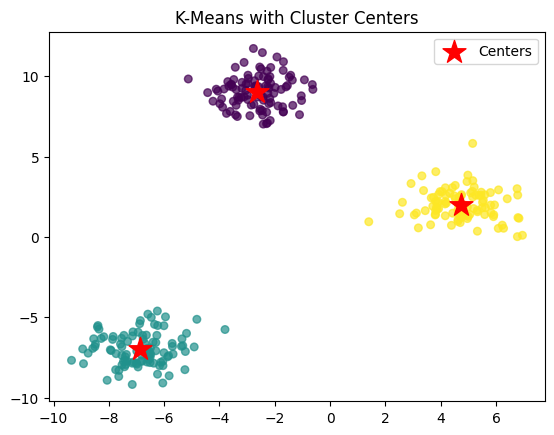

In [17]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=3, random_state=42)

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

# Plot data points
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30, alpha=0.7)

# Plot cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=300, marker='*', label='Centers')
plt.title('K-Means with Cluster Centers')
plt.legend()
plt.show()

### Q38. Load the Iris dataset, cluster with DBSCAN, and print how many samples were identified as noise.

In [18]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

iris = load_iris()
X = StandardScaler().fit_transform(iris.data)

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X)

noise_count = list(labels).count(-1)
print(f'Number of noise samples: {noise_count}')
print(f'Total samples: {len(labels)}')

Number of noise samples: 34
Total samples: 150


### Q39. Generate synthetic non-linearly separable data using make_moons, apply K-Means, and visualize the clustering result.

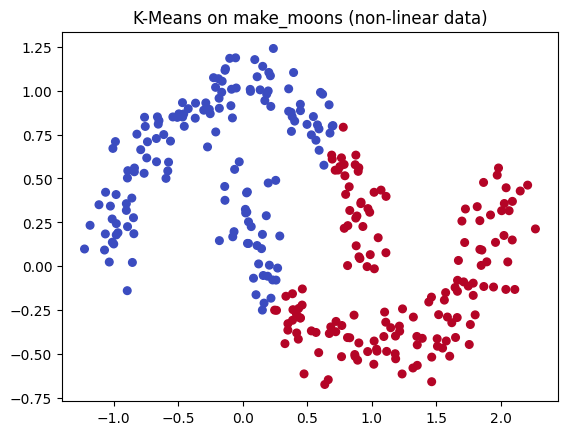

In [19]:
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

# K-Means (note: will not cluster well on non-linear data)
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='coolwarm', s=30)
plt.title('K-Means on make_moons (non-linear data)')
plt.show()
# Note: K-Means does poorly here because clusters are not round

### Q40. Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans and visualize with a 3D scatter plot.

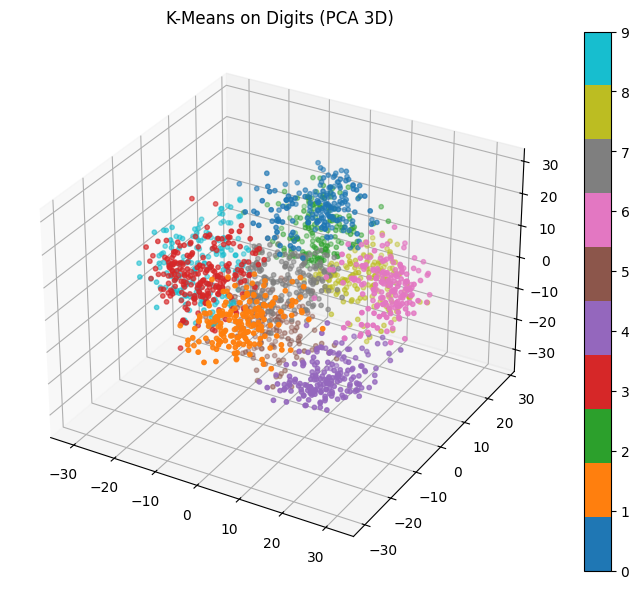

In [20]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

digits = load_digits()
X = digits.data

# Reduce to 3D
pca = PCA(n_components=3)
X_3d = pca.fit_transform(X)

# K-Means
kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(X_3d)

# 3D plot
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=labels, cmap='tab10', s=10)
ax.set_title('K-Means on Digits (PCA 3D)')
plt.colorbar(sc)
plt.show()

### Q41. Generate synthetic blobs with 5 centers and apply KMeans. Then use silhouette_score to evaluate the clustering.

In [21]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=300, centers=5, random_state=42)

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)

score = silhouette_score(X, labels)
print(f'Silhouette Score: {score:.4f}')

Silhouette Score: 0.6530


### Q42. Load the Breast Cancer dataset, reduce dimensionality using PCA, and apply Agglomerative Clustering. Visualize in 2D.

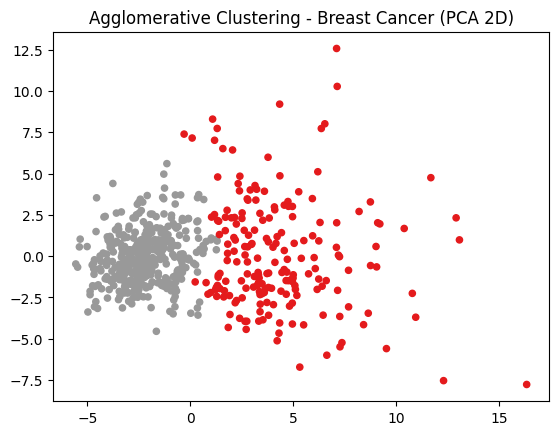

In [22]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

cancer = load_breast_cancer()
X = StandardScaler().fit_transform(cancer.data)

# PCA to 2D
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# Agglomerative
agg = AgglomerativeClustering(n_clusters=2)
labels = agg.fit_predict(X_2d)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='Set1', s=20)
plt.title('Agglomerative Clustering - Breast Cancer (PCA 2D)')
plt.show()

### Q43. Generate noisy circular data using make_circles and visualize clustering results from KMeans and DBSCAN side-by-side.

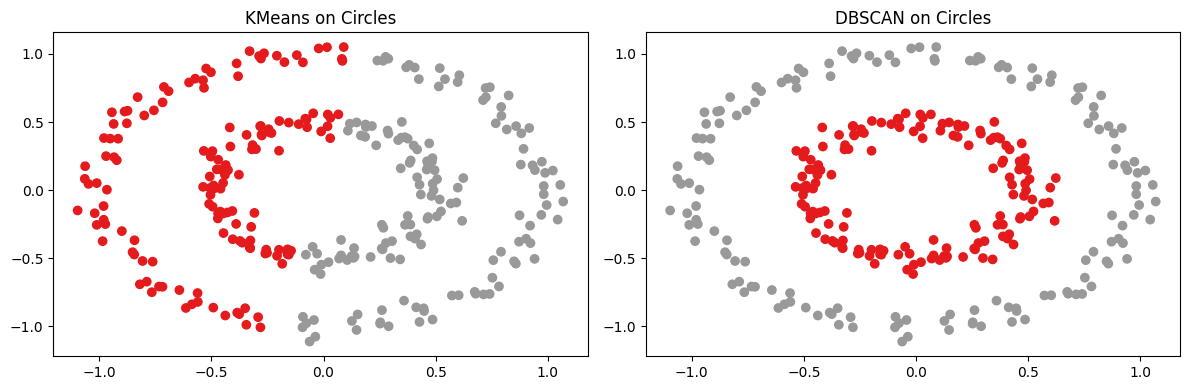

In [23]:
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt

X, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

km_labels = KMeans(n_clusters=2, random_state=42).fit_predict(X)
db_labels = DBSCAN(eps=0.2, min_samples=5).fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X[:, 0], X[:, 1], c=km_labels, cmap='Set1')
axes[0].set_title('KMeans on Circles')

axes[1].scatter(X[:, 0], X[:, 1], c=db_labels, cmap='Set1')
axes[1].set_title('DBSCAN on Circles')

plt.tight_layout()
plt.show()

### Q44. Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans clustering.

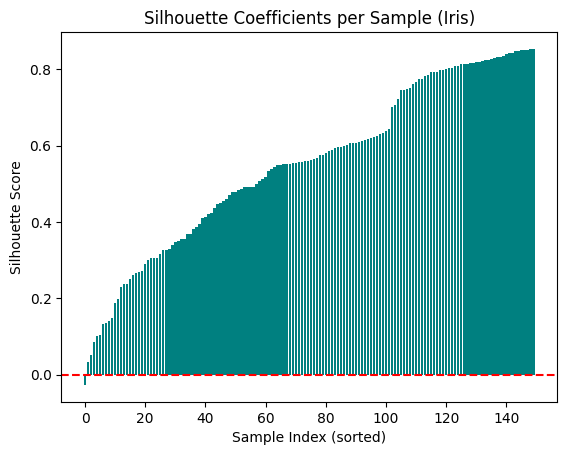

In [24]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

iris = load_iris()
X = iris.data

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

# Silhouette score per sample
sil_vals = silhouette_samples(X, labels)

plt.bar(range(len(sil_vals)), sorted(sil_vals), color='teal')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Silhouette Coefficients per Sample (Iris)')
plt.xlabel('Sample Index (sorted)')
plt.ylabel('Silhouette Score')
plt.show()

### Q45. Generate synthetic data using make_blobs and apply Agglomerative Clustering with 'average' linkage. Visualize clusters.

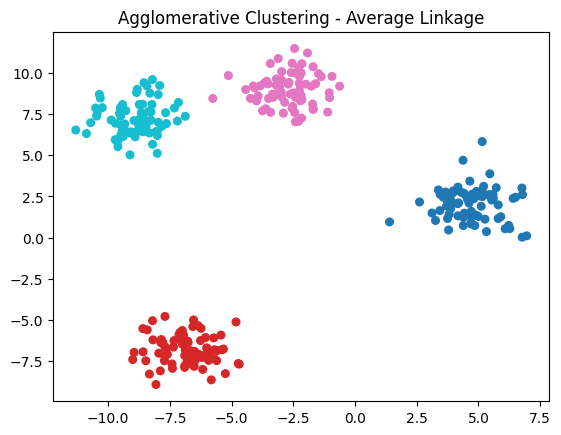

In [25]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

# Average linkage
agg = AgglomerativeClustering(n_clusters=4, linkage='average')
labels = agg.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=30)
plt.title('Agglomerative Clustering - Average Linkage')
plt.show()

### Q46. Load the Wine dataset, apply KMeans, and visualize the cluster assignments in a seaborn pairplot (first 4 features).

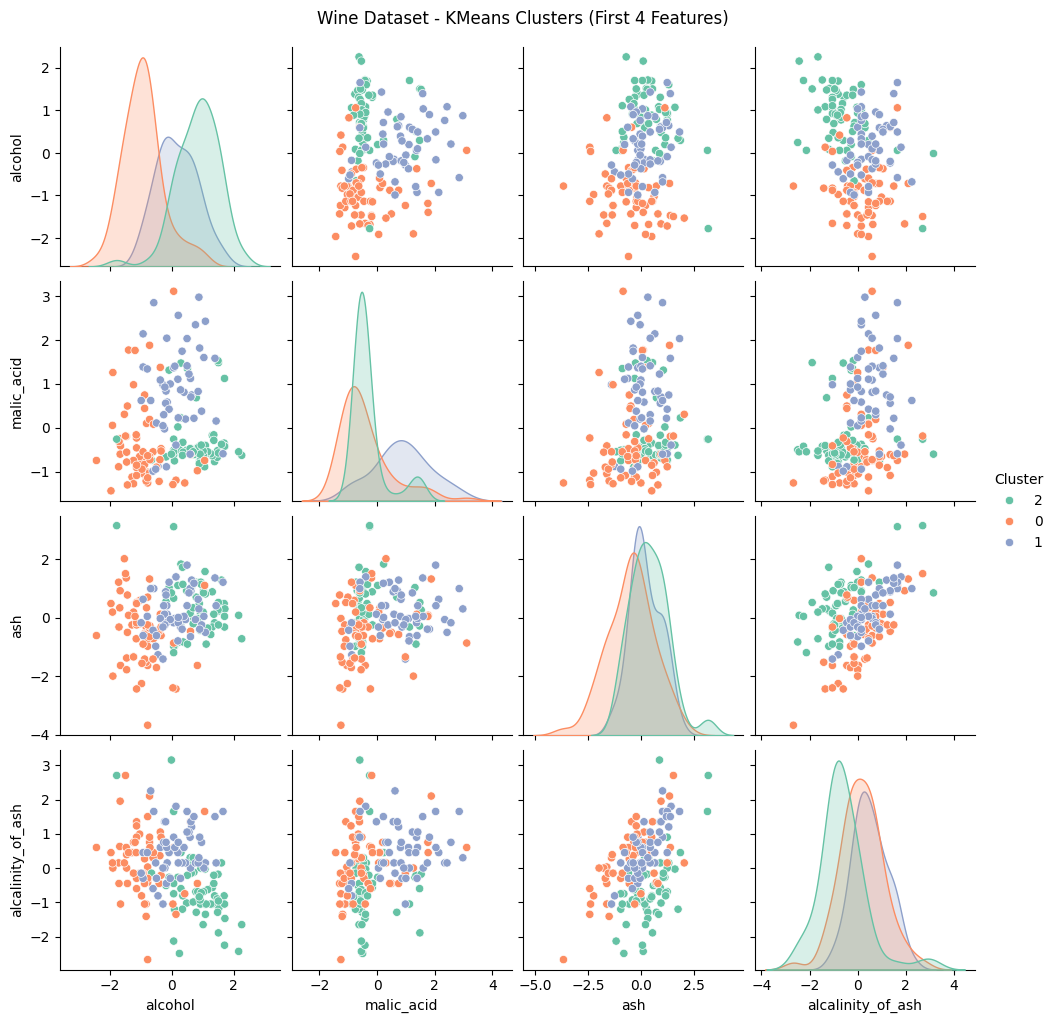

In [26]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

wine = load_wine()
X = StandardScaler().fit_transform(wine.data)

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

# Use first 4 features
df = pd.DataFrame(X[:, :4], columns=wine.feature_names[:4])
df['Cluster'] = labels.astype(str)

sns.pairplot(df, hue='Cluster', palette='Set2')
plt.suptitle('Wine Dataset - KMeans Clusters (First 4 Features)', y=1.02)
plt.show()

### Q47. Generate noisy blobs using make_blobs and use DBSCAN to identify both clusters and noise points. Print the count.

In [27]:
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
import numpy as np

# Generate noisy blobs
X, _ = make_blobs(n_samples=400, centers=3, cluster_std=1.5, random_state=42)

dbscan = DBSCAN(eps=1.0, min_samples=5)
labels = dbscan.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f'Number of clusters found: {n_clusters}')
print(f'Number of noise points: {n_noise}')

Number of clusters found: 3
Number of noise points: 29


### Q48. Load the Digits dataset, reduce dimensions using t-SNE, then apply Agglomerative Clustering and plot the clusters.

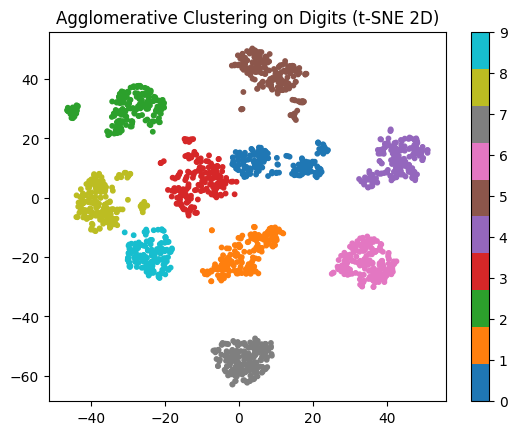

In [28]:
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

digits = load_digits()
X = digits.data

# Reduce with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

# Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=10)
labels = agg.fit_predict(X_tsne)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=10)
plt.title('Agglomerative Clustering on Digits (t-SNE 2D)')
plt.colorbar()
plt.show()